In [1]:
import pandas as pd 


In [76]:
df = pd.read_csv("../Data/swiggy.csv")

In [77]:
print(df.head)

<bound method NDFrame.head of             id                      name      city rating     rating_count  \
0       567335            AB FOODS POINT    Abohar     --  Too Few Ratings   
1       531342         Janta Sweet House    Abohar    4.4      50+ ratings   
2       158203         theka coffee desi    Abohar    3.8     100+ ratings   
3       187912                 Singh Hut    Abohar    3.7      20+ ratings   
4       543530             GRILL MASTERS    Abohar     --  Too Few Ratings   
...        ...                       ...       ...    ...              ...   
148536  553122          The Food Delight  Yavatmal     --  Too Few Ratings   
148537  562647  MAITRI FOODS & BEVERAGES  Yavatmal     --  Too Few Ratings   
148538  559435           Cafe Bella Ciao  Yavatmal     --  Too Few Ratings   
148539  418989               GRILL ZILLA  Yavatmal     --  Too Few Ratings   
148540  447770            Lazeez kitchen  Yavatmal     --  Too Few Ratings   

         cost                    

In [78]:
print(df.shape)

(148541, 11)


In [79]:
print(df.columns)

Index(['id', 'name', 'city', 'rating', 'rating_count', 'cost', 'cuisine',
       'lic_no', 'link', 'address', 'menu'],
      dtype='object')


In [80]:
print(df.info)

<bound method DataFrame.info of             id                      name      city rating     rating_count  \
0       567335            AB FOODS POINT    Abohar     --  Too Few Ratings   
1       531342         Janta Sweet House    Abohar    4.4      50+ ratings   
2       158203         theka coffee desi    Abohar    3.8     100+ ratings   
3       187912                 Singh Hut    Abohar    3.7      20+ ratings   
4       543530             GRILL MASTERS    Abohar     --  Too Few Ratings   
...        ...                       ...       ...    ...              ...   
148536  553122          The Food Delight  Yavatmal     --  Too Few Ratings   
148537  562647  MAITRI FOODS & BEVERAGES  Yavatmal     --  Too Few Ratings   
148538  559435           Cafe Bella Ciao  Yavatmal     --  Too Few Ratings   
148539  418989               GRILL ZILLA  Yavatmal     --  Too Few Ratings   
148540  447770            Lazeez kitchen  Yavatmal     --  Too Few Ratings   

         cost                  

In [81]:
df.isnull().sum()

id                0
name             86
city              0
rating           86
rating_count     86
cost            131
cuisine          99
lic_no          229
link              0
address          86
menu              0
dtype: int64

In [82]:
df.describe()

,id
count,148541.000000
mean,363466.378912
std,167890.977174
min,211.000000
25%,233320.000000
50%,412628.000000
75%,502223.000000
max,581031.000000


In [ ]:

#- Pehle cost clean karo BEFORE dropna
df['cost'] = df['cost'].astype(str).str.replace('₹', '').str.strip()
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')

In [ ]:

# - Sirf important columns ki null rows drop karo
df.dropna(subset=['name', 'city', 'rating', 'cuisine'], inplace=True)


In [85]:
# Step 4 - lic_no drop karo
df = df.drop(columns=['lic_no'])


In [88]:
# Step 5 - Verify karo
print("Shape:", df.shape)
print("\nNull values:")
print(df.isnull().sum())

Shape: (148442, 10)

Null values:
id               0
name             0
city             0
rating           0
rating_count     0
cost            44
cuisine          0
link             0
address          0
menu             0
dtype: int64


In [90]:
# Step 6 - Ab cost check karo
print("\nTop 10 by cost:")
print(df.sort_values(by='cost', ascending=False)[['name','cost']].head(10))


Top 10 by cost:
                             name      cost
70762              KOHINOOR HOTEL  300350.0
21626            Oasis restaurant    8000.0
47552      VENOM CLUB AND KITCHEN    6000.0
47817        Aggarwal sweet india    5023.0
107779           SHAAN RESTAURANT    5000.0
4930    Rock N Shawarma Take Away    3999.0
109414   Ministry of Crab, Mumbai    3500.0
23334                 Olive Beach    3500.0
76454                  SRS HAVMOR    3360.0
75847            Sofra food court    3200.0


In [92]:
# Cost ke NaN ko median se fill karo
# df['cost'].fillna(df['cost'].median(), inplace=True)

df['cost'] = df['cost'].fillna(df['cost'].median())


In [93]:
# City clean karo
df['city_clean'] = df['city'].str.split(',').str[-1].str.strip()


In [94]:
# Verify
print("Cost null:", df['cost'].isnull().sum())
print("\nTop 10 clean cities:")
print(df['city_clean'].value_counts().head(10))

Cost null: 0

Top 10 clean cities:
city_clean
Bangalore     14943
Delhi         14071
Pune          12433
Hyderabad     10011
Chennai        9954
Kolkata        8280
Mumbai         6070
Ahmedabad      3517
Chandigarh     3320
Lucknow        2845
Name: count, dtype: int64


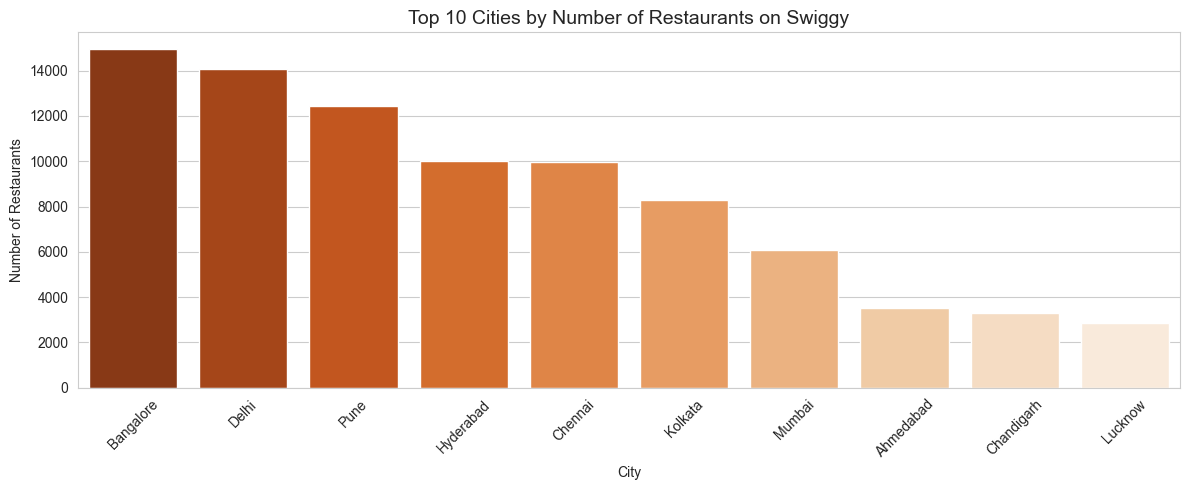

✅ Chart 1 saved!


In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(12, 5))
city_data = df['city_clean'].value_counts().head(10)
sns.barplot(x=city_data.index, y=city_data.values, 
            hue=city_data.index, palette='Oranges_r', legend=False)
plt.title('Top 10 Cities by Number of Restaurants on Swiggy', fontsize=14)
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../charts/chart1_top_cities.png', dpi=150)
plt.show()
print("✅ Chart 1 saved!")

In [96]:
import os

# Charts folder banao automatically
os.makedirs('../charts', exist_ok=True)
print("✅ Charts folder ready!")

✅ Charts folder ready!


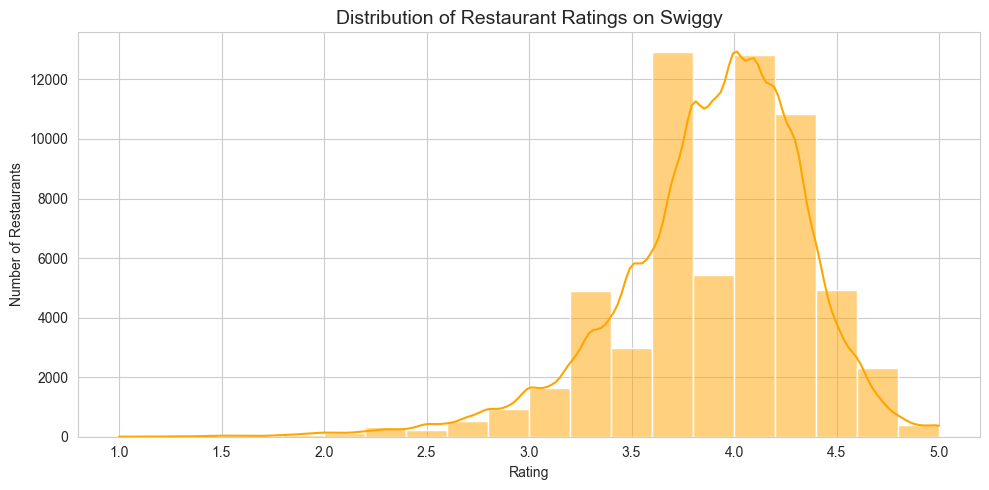

✅ Chart 2 saved!


In [99]:
# Chart 2 - Rating Distribution
plt.figure(figsize=(10, 5))
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
sns.histplot(df['rating'].dropna(), bins=20, color='orange', kde=True)
plt.title('Distribution of Restaurant Ratings on Swiggy', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('../charts/chart2_rating_distribution.png', dpi=150)
plt.show()
print("✅ Chart 2 saved!")

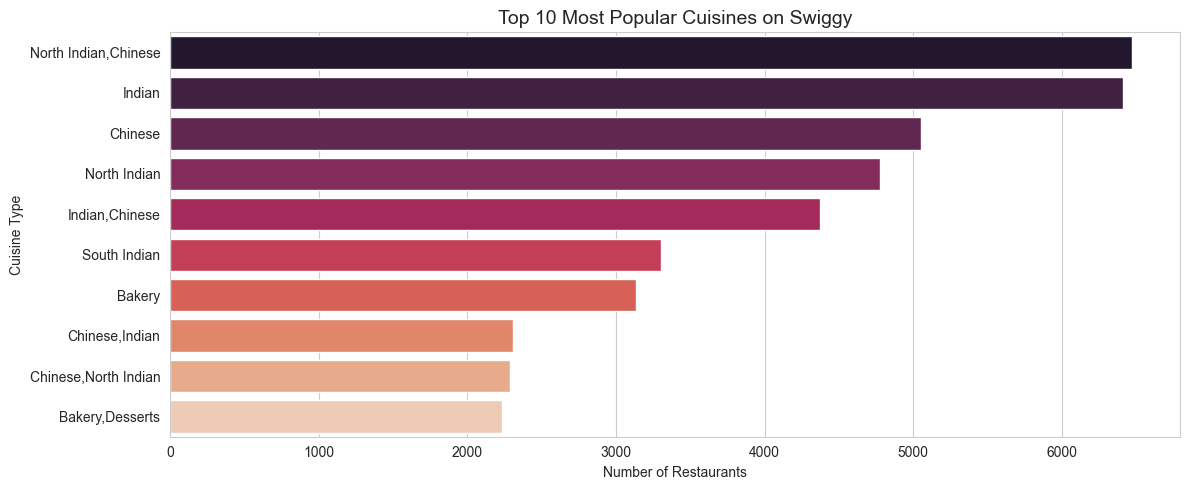

✅ Chart 3 saved!


In [100]:
# Chart 3 - Top 10 Cuisines
plt.figure(figsize=(12, 5))
cuisine_data = df['cuisine'].value_counts().head(10)
sns.barplot(x=cuisine_data.values, y=cuisine_data.index,
            hue=cuisine_data.index, palette='rocket', legend=False)
plt.title('Top 10 Most Popular Cuisines on Swiggy', fontsize=14)
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.savefig('../charts/chart3_top_cuisines.png', dpi=150)
plt.show()
print("✅ Chart 3 saved!")

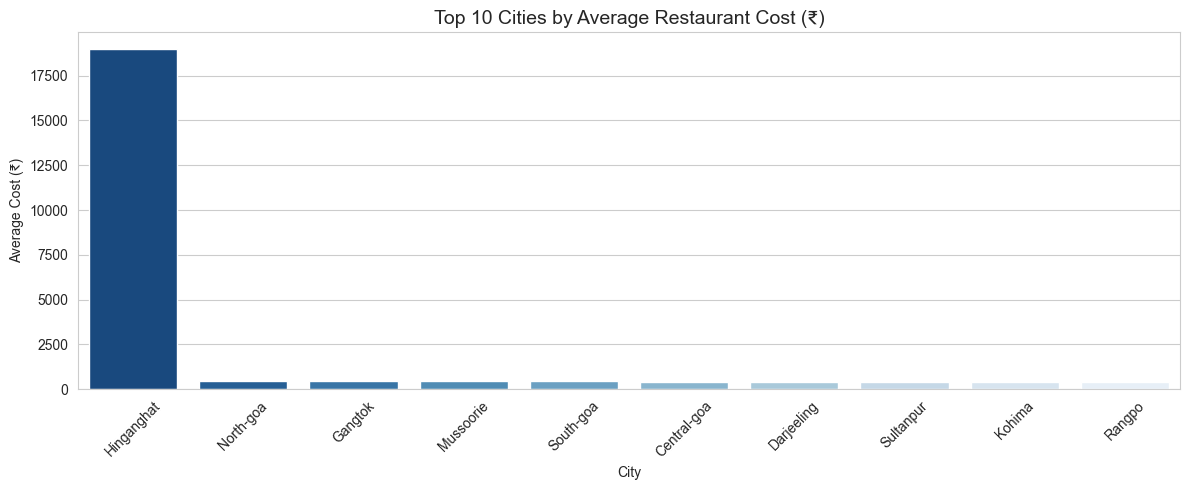

✅ Chart 4 saved!


In [101]:
# Chart 4 - Average Cost by City
plt.figure(figsize=(12, 5))
avg_cost = df.groupby('city_clean')['cost'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_cost.index, y=avg_cost.values,
            hue=avg_cost.index, palette='Blues_r', legend=False)
plt.title('Top 10 Cities by Average Restaurant Cost (₹)', fontsize=14)
plt.xlabel('City')
plt.ylabel('Average Cost (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../charts/chart4_avg_cost.png', dpi=150)
plt.show()
print("✅ Chart 4 saved!")

In [102]:
rider_df = pd.read_csv("../Data/Rider-Info.csv")

In [103]:
rider_df.head()

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time
0,2021-01-26 02:21:35,556753,2021-01-26 00:00:00,2021-01-26 02:21:59,2021-01-26 02:22:08,2021-01-26 02:32:51,2021-01-26 02:49:47,11696,1.5666,2.65,46.0,46.0,0,0.0,621.0,NaN,NaN,NaN,NaN,NaN
1,2021-01-26 02:33:16,556754,2021-01-26 00:00:00,2021-01-26 02:33:57,2021-01-26 02:34:45,2021-01-26 02:50:25,2021-01-26 03:11:15,18117,2.5207,2.76,8.0,8.0,0,0.0,105.0,NaN,NaN,NaN,3.266667,NaN
2,2021-01-26 02:39:49,556755,2021-01-26 00:00:00,2021-01-26 02:39:57,2021-01-26 02:40:13,2021-01-26 02:56:00,2021-01-26 03:12:46,18623,2.2074,4.80,1.0,1.0,0,0.0,66.0,NaN,NaN,NaN,9.816667,NaN
3,2021-01-26 02:47:53,556756,2021-01-26 00:00:00,2021-01-26 02:48:25,2021-01-26 02:49:06,2021-01-26 03:21:51,2021-01-26 03:41:05,15945,2.1894,6.38,1.0,1.0,0,0.0,127.0,NaN,NaN,NaN,17.533333,NaN
4,2021-01-26 03:06:30,556757,2021-01-26 00:00:00,2021-01-26 03:07:21,2021-01-26 03:07:57,2021-01-26 03:31:38,2021-01-26 04:00:15,17589,2.7870,4.01,34.0,34.0,0,0.0,84.0,NaN,NaN,NaN,1.350000,NaN


In [104]:
rider_df.shape

(450000, 20)

In [105]:
rider_df.columns

Index(['order_time', 'order_id', 'order_date', 'allot_time', 'accept_time',
       'pickup_time', 'delivered_time', 'rider_id', 'first_mile_distance',
       'last_mile_distance', 'alloted_orders', 'delivered_orders', 'cancelled',
       'undelivered_orders', 'lifetime_order_count', 'reassignment_method',
       'reassignment_reason', 'reassigned_order', 'session_time',
       'cancelled_time'],
      dtype='object')

In [106]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450000 entries, 0 to 449999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_time            450000 non-null  object 
 1   order_id              450000 non-null  int64  
 2   order_date            450000 non-null  object 
 3   allot_time            450000 non-null  object 
 4   accept_time           449843 non-null  object 
 5   pickup_time           447579 non-null  object 
 6   delivered_time        444782 non-null  object 
 7   rider_id              450000 non-null  int64  
 8   first_mile_distance   450000 non-null  float64
 9   last_mile_distance    450000 non-null  float64
 10  alloted_orders        433052 non-null  float64
 11  delivered_orders      432659 non-null  float64
 12  cancelled             450000 non-null  int64  
 13  undelivered_orders    432659 non-null  float64
 14  lifetime_order_count  449947 non-null  float64
 15  

In [107]:
rider_df.isnull().sum()

order_time                   0
order_id                     0
order_date                   0
allot_time                   0
accept_time                157
pickup_time               2421
delivered_time            5218
rider_id                     0
first_mile_distance          0
last_mile_distance           0
alloted_orders           16948
delivered_orders         17341
cancelled                    0
undelivered_orders       17341
lifetime_order_count        53
reassignment_method     436256
reassignment_reason     436247
reassigned_order        436247
session_time              3675
cancelled_time          444782
dtype: int64

In [108]:
## Order time ko datetime mein convert karo

rider_df['order_time'] = pd.to_datetime(rider_df['order_time'])

In [109]:
 ## Delivered time ko datetime mein convert karo

rider_df['delivered_time'] = pd.to_datetime(rider_df['delivered_time'])

In [110]:
# Delivery duration calculate karo

rider_df['delivery_duration_min'] = (
    rider_df['delivered_time'] - rider_df['order_time']
).dt.total_seconds() / 60

In [111]:
# Negative aur unrealistic values remove karo

rider_df = rider_df[
    (rider_df['delivery_duration_min'] > 0) & 
    (rider_df['delivery_duration_min'] < 180)
]

In [112]:
print("Shape:", rider_df.shape)
print("\nAverage delivery time:", round(rider_df['delivery_duration_min'].mean(), 2), "minutes")
print("Min delivery time:", round(rider_df['delivery_duration_min'].min(), 2), "minutes")
print("Max delivery time:", round(rider_df['delivery_duration_min'].max(), 2), "minutes")

Shape: (444382, 21)

Average delivery time: 31.63 minutes
Min delivery time: 1.05 minutes
Max delivery time: 179.77 minutes


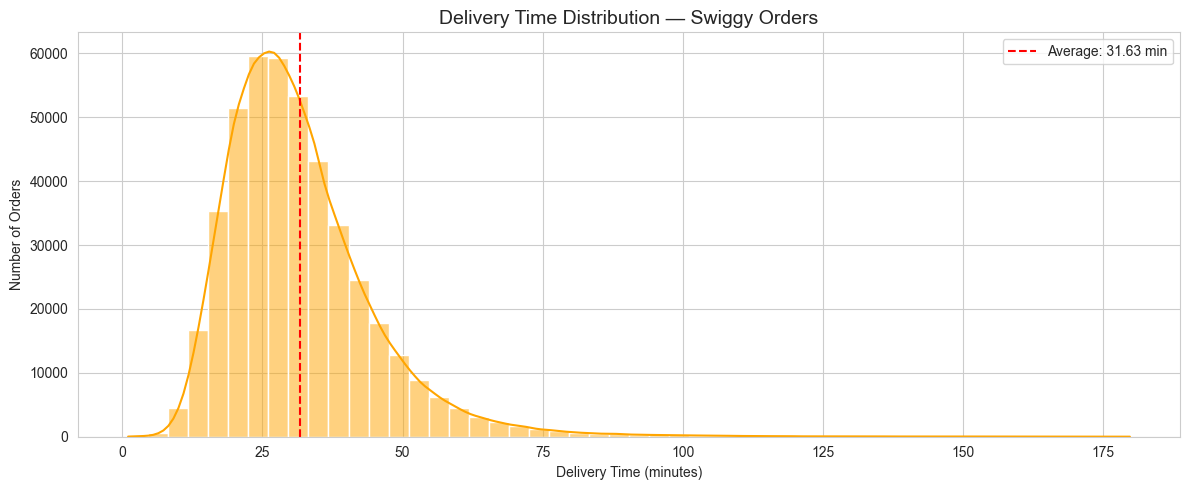

✅ Chart 5 saved!


In [113]:
# Chart 5 - Delivery Time Distribution
plt.figure(figsize=(12, 5))
sns.histplot(rider_df['delivery_duration_min'], bins=50, color='orange', kde=True)
plt.title('Delivery Time Distribution — Swiggy Orders', fontsize=14)
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Number of Orders')
plt.axvline(x=31.63, color='red', linestyle='--', label='Average: 31.63 min')
plt.legend()
plt.tight_layout()
plt.savefig('../charts/chart5_delivery_time.png', dpi=150)
plt.show()
print("✅ Chart 5 saved!")

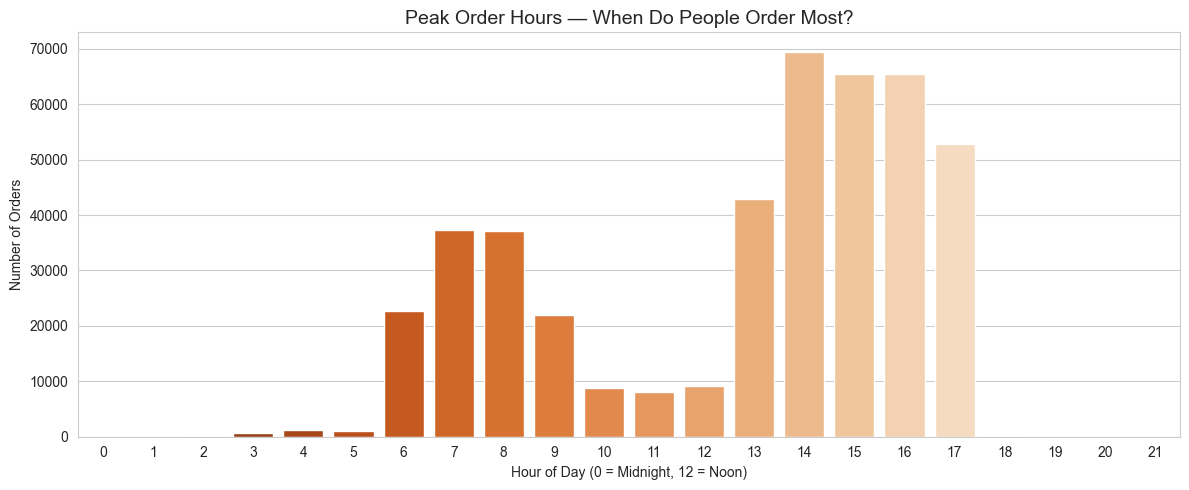

✅ Chart 6 saved!


In [114]:
# Chart 6 - Peak Order Hours
rider_df['order_hour'] = rider_df['order_time'].dt.hour

plt.figure(figsize=(12, 5))
hour_data = rider_df['order_hour'].value_counts().sort_index()
sns.barplot(x=hour_data.index, y=hour_data.values,
            hue=hour_data.index, palette='Oranges_r', legend=False)
plt.title('Peak Order Hours — When Do People Order Most?', fontsize=14)
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../charts/chart6_peak_hours.png', dpi=150)
plt.show()
print("✅ Chart 6 saved!")

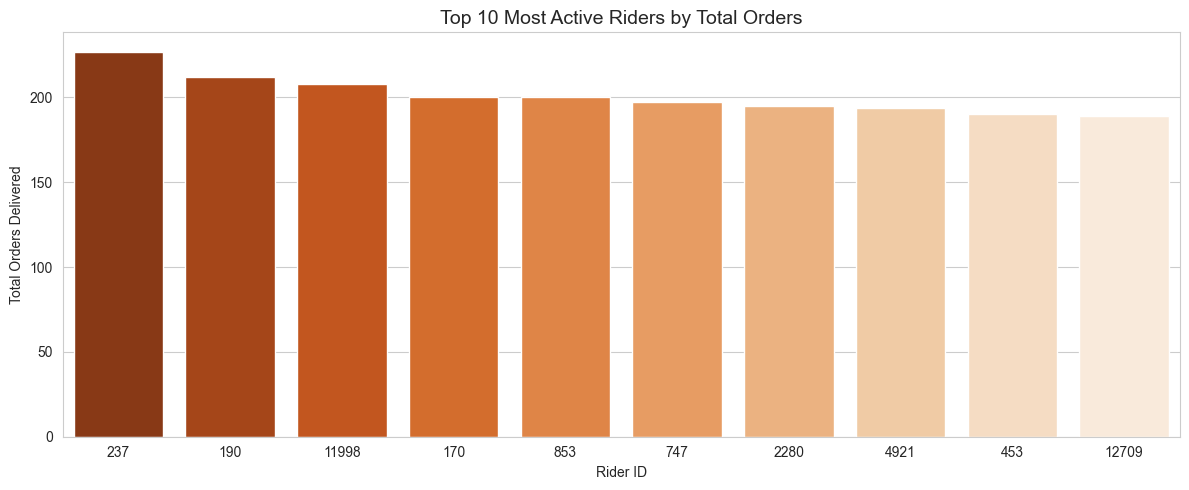

✅ Chart 7 saved!


In [117]:
# Chart 7 - Top 10 Riders by Most Orders
plt.figure(figsize=(12, 5))

top_riders = rider_df.groupby('rider_id')['order_id'].count().sort_values(ascending=False).head(10)

sns.barplot(x=top_riders.index.astype(str), y=top_riders.values,
            hue=top_riders.index.astype(str), palette='Oranges_r', legend=False)

plt.title('Top 10 Most Active Riders by Total Orders', fontsize=14)
plt.xlabel('Rider ID')
plt.ylabel('Total Orders Delivered')
plt.tight_layout()
plt.savefig('../charts/chart7_top_riders.png', dpi=150)
plt.show()
print("✅ Chart 7 saved!")

In [116]:
print(rider_df['cancelled'].value_counts())

cancelled
0    444382
Name: count, dtype: int64


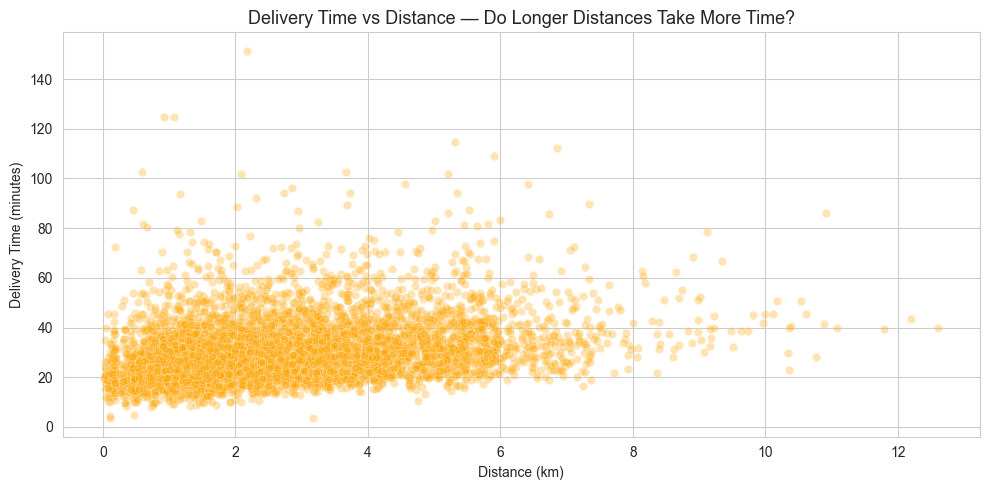

✅ Chart 8 saved!


In [118]:
# Chart 8 - Delivery Time vs Distance (Scatter Plot)
plt.figure(figsize=(10, 5))

# Sample lo — 5000 rows — warna chart slow hoga
sample_df = rider_df.sample(5000, random_state=42)

sns.scatterplot(x=sample_df['last_mile_distance'], 
                y=sample_df['delivery_duration_min'],
                alpha=0.3, color='orange')

plt.title('Delivery Time vs Distance — Do Longer Distances Take More Time?', fontsize=13)
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (minutes)')
plt.tight_layout()
plt.savefig('../charts/chart8_time_vs_distance.png', dpi=150)
plt.show()
print("✅ Chart 8 saved!")

In [119]:
# Cleaned restaurant data save karo
df.to_csv('../Data/swiggy_cleaned.csv', index=False)
print("✅ Restaurant data saved!")

# Cleaned rider data save karo
rider_df.to_csv('../Data/rider_cleaned.csv', index=False)
print("✅ Rider data saved!")

✅ Restaurant data saved!
✅ Rider data saved!


In [122]:
pip install pyodbc

Note: you may need to restart the kernel to use updated packages.


In [123]:
import pyodbc
import pandas as pd

# Connection banao
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=DESKTOP-OPK9OEH;'
    'DATABASE=swiggy_analytics;'
    'Trusted_Connection=yes;'
)

print("✅ SQL Server connected!")

✅ SQL Server connected!


In [124]:
pip install sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 5.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ---------------

In [125]:
from sqlalchemy import create_engine

# Engine banao
engine = create_engine(
    'mssql+pyodbc://DESKTOP-OPK9OEH/swiggy_analytics?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes'
)

# Restaurant data load karo
df.to_sql('restaurants', engine, if_exists='replace', index=False)
print("✅ Restaurants table created!")

# Rider data load karo
rider_df.to_sql('delivery', engine, if_exists='replace', index=False)
print("✅ Delivery table created!")

✅ Restaurants table created!
✅ Delivery table created!
